### Updated code for the calibration

In [1]:
# Importing all the needed libraries
import pandas as pd
import datetime
import numpy as np
from yahoo_fin.stock_info import get_data
import matplotlib.pylab as plt
from sklearn.linear_model import LinearRegression
import py_vollib_vectorized
import warnings
warnings.filterwarnings("ignore")

### Import SPX stock price history from Yahoo Finance

,open,high,low,close,adjclose,volume,ticker
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1202.079956,1510800000,^GSPC
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1188.050049,1721000000,^GSPC
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1183.739990,1738900000,^GSPC
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1187.890015,1569100000,^GSPC
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1186.189941,1477900000,^GSPC


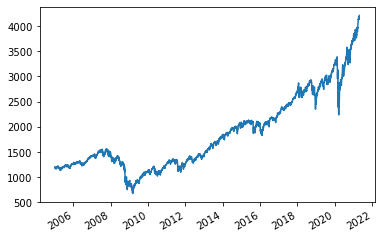

In [2]:
# start and end dates for the data you want to download
start_date = "2005-01-01"
end_date = "2021-04-30"
# get the stock price data for the selected dates
dfspx =  get_data("^GSPC", start_date=start_date, end_date=end_date)
#dfspx.to_csv('dfspx.csv', index=True)
# plotting closing prices
dfspx["close"].plot();
# plotting the data corresponding to the first five dates
dfspx.head()

### (local version for offline work)

In [3]:
# instead of downloading the data from yahoo finance use the one in the folder
# (this is suitable to be used when working offline)
dfspx = pd.read_csv('dfspx.csv', index_col=0)
dfspx.index = pd.to_datetime(dfspx.index, format='%Y-%m-%d')
# print the data corresponding to the first five dates
dfspx.head()

,open,high,low,close,adjclose,volume,ticker
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1202.079956,1510800000,^GSPC
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1188.050049,1721000000,^GSPC
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1183.739990,1738900000,^GSPC
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1187.890015,1569100000,^GSPC
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1186.189941,1477900000,^GSPC


### Import and clean option prices data

In [4]:
class spxCboeOptionPrices():
    def __init__(self):
        # building a dictionary to index the CBOE option prices data
        self.dfDict = {}
        return None
    
    # downloading the option prices data in within a specified frame of time 
    # (initial and terminal date given)
    def getStock(self, start_date, end_date):
        self.dfspx =  get_data("^GSPC", start_date=start_date, end_date=end_date)
    
    # using the (previously downloaded option prices data)
    def getStock_local(self, dfspx):
        self.dfspx =  dfspx
    
    # function to concatenate different sets of data
    def addData(self, files):
        # directory where the data are
        pathToFile = ""
        
        self.df = pd.read_csv(files[0])
        for f in files[1:]:
            dfTemp = pd.read_csv(f)
            self.df = pd.concat([self.df, dfTemp])
    
    # cleaning the data and making them ready to be used
    def clean(self):
        self.df = self.df.drop(['secid', 'issuer', 'optionid', 'index_flag', 'exercise_style'], axis=1)
        self.df["exdate"] = pd.to_datetime(self.df['exdate'], format='%Y%m%d')
        self.df["date"] = pd.to_datetime(self.df['date'], format='%Y%m%d')
        ## remove all the lines where the bid price is 0
        # df = df.loc[(df['best_bid'] <> 0.)] 
        ## mid Prices
        self.df['midP'] = 0.5*(self.df['best_offer'] + self.df['best_bid']) 
        
        ## convert maturities into time to maturity (in year)
        self.df['maturity'] = (self.df['exdate'] - self.df['date']).dt.days/ 365. #/ np.timedelta64(1, 'Y')
        self.df.rename(columns={'strike_price': 'strike'}, inplace=True)
        self.df['strike'] = self.df['strike']/1000.

        ## Remove all the zero volume rows"
        temp_size_allvolumes = self.df.size
        self.df = self.df[self.df["volume"] > 0]
        temp_size_positivevolumes = self.df.size
        print("Number of data points: ", len(self.df))
        print("Percentage removed because of 0 volume: ", np.round(100*((temp_size_allvolumes - temp_size_positivevolumes) / temp_size_allvolumes), 1), "%")
        
        ## Gets a list of all days
        self.allDates = self.df.drop_duplicates('date')['date'].tolist() 
        
    # adding the spot price to each date
    def addSpot(self, dfspx):
        for t in self.allDates:
            St = dfspx.loc[dfspx.index == t]['close'].values[0] 
            ## current value of the S&P
            self.df.loc[(self.df['date'] == t), 'Spot'] = St
    
    def computeFwdDF_all(self, rr = [0.99, 1.01]):
        
        print("All dates: ", self.allDates[:4])
        for t in self.allDates:
            self.computeFwdDF(t, rr)
            

    def computeFwdDF(self, currentDate, rr = [0.99, 1.01]):
        ## compute the forwards and discount Factors for a given currentDate
        #rr: bounds to eliminate the far-away strikes, i.e. K in (rd*St, ru*St)
        
        dfT = self.df.loc[self.df['date']==currentDate]
        print("*****************************************")
        print("t = ", currentDate)
        print("Data: ", dfT.size)
                
        dfTK = dfT.loc[(dfT['strike']>rr[0]*dfT["Spot"]) & (dfT['strike']<rr[1]*dfT["Spot"])]
        print("Data extract: ", dfTK.size)
        dfT["Fwd"] = 0.
        dfT["discountFactor"] = 0.
        
        ## Gets an array of all maturities on that day
        allMats = dfT.drop_duplicates('exdate')['exdate'].tolist()
        print("All maturities: ", allMats)
        for tau in allMats:
            print("++++++++++++++++++")

            ddC = (dfTK.loc[(dfTK['exdate']==tau) & (dfTK['cp_flag']=="C")]).sort_values(by=['strike'], ascending=True)
            ddP = (dfTK.loc[(dfTK['exdate']==tau) & (dfTK['cp_flag']=="P")]).sort_values(by=['strike'], ascending=True)

            strikesC = ((ddC.drop_duplicates('strike')['strike']).sort_values())
            strikesP = ((ddP.drop_duplicates('strike')['strike']).sort_values())
            strikes  = ((pd.merge(strikesC.to_frame(), strikesP.to_frame(), on='strike')).iloc[:,0])
            print(tau, " || ", ddC.size, " || ", ddP.size, " || ", len(strikesC), " || ", len(strikesP))

            parity = [(ddC.loc[ddC['strike']==K]['midP'].values[0]  - ddP.loc[ddP['strike']==K]['midP'].values[0]) for K in strikes.tolist()]
            model  = LinearRegression().fit(strikes.values.reshape((-1, 1)), parity)
            
            discountFactor = - model.coef_[0]
            forward = model.intercept_ / discountFactor
            
            dfT.loc[(dfT['exdate'] == tau), 'Fwd'] = forward
            dfT.loc[(dfT['exdate'] == tau), 'discountFactor'] = discountFactor
            
        self.dfDict[currentDate] = (dfT, allMats)

    def computeFwdDF_noneed(self):
        # for each date t (among all the dates we are considering)
        for t in self.allDates:
            # for the data where the date is t
            dfT = self.df.loc[self.df['date'] == t]
            # store in a list of all the maturities (for this expiration date t)
            allMats = dfT.drop_duplicates('exdate')['exdate'].tolist()
            # initialise the dictionary to empty
            self.dfDict[t] = []
            # for each tau (one of the aforementioned maturities for the date t) 
            for tau in allMats:
                # set dfTtau to be the data corresponding to that maturity tau
                dfTtau = dfT[dfT["exdate"] == tau]
                # add the couple (data, maturity) to the t-entry of the dictionary
                self.dfDict[t].append((dfTtau, tau))

In [5]:
# define the class
cboeData = spxCboeOptionPrices()
# add the data Jack gave us
files = ["optionMetricsSpx2005.csv"]
cboeData.addData(files)
# clean the data and make them ready to be used
cboeData.clean()
# add the spot prices taken from yahoo finance
cboeData.addSpot(dfspx)

Number of data points:  52933
Percentage removed because of 0 volume:  64.6 %


Add details for a specified set of dates (and add them in a dictionary)

In [6]:
# create a dictionary where for each date you have a couple with data and exdate
cboeData.computeFwdDF_noneed()

# CALIBRATION (slice by slice)

In [7]:
from scipy.optimize import minimize

### Data selection

Quadratic rough Heston \cite{gatheral2020quadratic}: For $H\in(0,1/2),\lambda,\eta, a, b,c, \theta_0>0$

\begin{equation}
    \left\{\begin{aligned}
   &dS_t=S_t\sqrt{a(Z_t-b)^2+c}dB_t\\&
    Z_t=\frac{\lambda}{\Gamma(H+1/2)}\int_0^{t}(t-s)^{H-1/2}(\theta_0(s)-Z_s)ds+\frac{\lambda\eta}{\Gamma(H+1/2)}\int_0^t(t-s)^{H-1/2}\sqrt{(a(Z_s-b)^2+c)}dW_t
      \end{aligned}\right.
\end{equation}
where $B, W$ are one-dimensional Brownian motions (possibly correlated) and $$\theta_0(t)=Z_0t^{-H+1/2}/(\lambda \Gamma(1/2-H).$$ After calibration they obtained the parameter values $H=0.01, \lambda=1.2, a=0.384, b=0.095, c=0.0025, Z_0=0.1$ In the deep calibration paper \cite{rosenbaum2021deep the calibrated parameters are given by 
$$\omega=(\lambda, \eta, a,b,c)=(2.5, 1.485, 0.401, 0.235, 0.001   ).$$




Our version is given by the RDE:

\begin{equation}
    \left\{\begin{aligned}
   &dS_t=S_t\sqrt{a(Z_t-b)^2+c}dB_t\\&
    dZ_t=\lambda(\theta_0-Z_t)dt+\lambda\eta \sqrt{(a(Z_t-b)^2+c)}dW^H_t,
      \end{aligned}\right.
\end{equation}
 $B=\rho W+\bar{\rho} \bar{W}$ for $\rho\in(-1,1),$ $\rho^2+\bar{\rho}^2=1,$  $W,\bar{W} $ are independent Bms and 
 $$ W^H_t=\frac{1}{\Gamma(H+1/2)}\int_0^t(t-s)^{H-1/2}dW_s.  $$
 

### Calibration class

In [8]:
class model_calibration():

    def __init__(self):
        # set some lower and upper bounds for the parameters to be calibrated
        self.calibBounds = ((-0.2,5.49),(0.01,5.2),(-.97, .5),(-1.5, 1.5), (-1., 1.))
        self.errorMessage = False
        
    # function to select the data corresponding to a specific date and maturity
    def select_data(self, data, select_date_ind, select_mat_ind):
        
        # check if the index for date falls in the data set        
        if (select_date_ind >= 0) & (select_date_ind < len(data.allDates)):
            # if so
            ## Select one particular day
            self.o = data.allDates[select_date_ind] 
            
            # check if (for the data on this date)the index for the maturity belongs to the data set     
            if (select_mat_ind >= 0) & (select_mat_ind < len(data.dfDict[self.o])):
                # if so
                ## extract data
                df_extract = data.dfDict[self.o][select_mat_ind]
                
            # if NOT error
            else:
                self.errorMessage = True
        # if NOT error
        else:
            self.errorMessage = True
        # if error, print error
        if self.errorMessage:
            print("No data available. Please choose other")
        # if NOT, do what you are supposed to:
        else:
            
            # the second entry of the data is the expiration date
            self.Tau = df_extract[1]
            # consider call options
            df = df_extract[0][df_extract[0]["cp_flag"] == "C"]
            # log forward moneyness
            df["logfwdmoneyness"] = -np.log(df["forward_price"] / df["strike"])
    
            self.data = df
            self.logStrikes = self.data["logfwdmoneyness"]
            self.ivs_market = self.data["impl_volatility"]
            
            self.maturity = self.data["maturity"].iloc[0]
            
    # Define a function that given the trajectories of Z computes S (via integration, 
    # indeed it is just and exponential martingale) and the from this computes the price of
    # call options for a given set of parameters and strike and time to maturity

    # This is the part we have to redo
    # as it should compute the iv in the rough model as a fuction of its parameters
    def iv_rough(self, params):
        """
        Compute the SVI implied volatility
        """
        lamb, eta, a, b, c = params
        
        # for this we are going to use imp_vol= py_vollib_vectorized.vectorized_implied_volatility(options_values, forward_values,  strikes_values,  time_to_expiry, r, callput_flag, dividends=0, model='black_scholes_merton', return_as='numpy', on_error='ignore')
    
        return np.sqrt((a + b * (rho*(self.logStrikes-m) + np.sqrt((self.logStrikes-m)**2 + sigma**2))) / self.maturity)
    
    # this should be fine as it is
    def lossFunction_ivs(self, params):
        """
        Compute the l2 loss function between the model implied vols and the market implied vols.
        """
        
        ivs = self.iv_rough(params)
        return np.sum([(a - b)**2 for (a,b) in zip(ivs, self.ivs_market)])
    
    # this should be fine as it is but the fact that we should choose carefully 
    # the set of parameters that we want to start from
    def calibrate(self, p_init = (2.5,1.485,0.401,0.235,0.001), print_options = [True, True]):
        
        self.optim = minimize(self.lossFunction_ivs, p_init, method='SLSQP', bounds=self.calibBounds, options={'ftolfloat': 1E-8})
        
        if print_options[0]:
            print("Optimal parameters: ")
            print("a = ", self.optim.x[0])
            print("b = ", self.optim.x[1])
            print('\u03C1 = ', self.optim.x[2])
            print("m = ", self.optim.x[3])
            print('\u03C3 = ', self.optim.x[4])
        
        if print_options[1]:
            plt.figure(figsize=(6, 3))
            plt.plot(self.logStrikes, self.ivs_market, 'bo', fillstyle='none')
            plt.plot(self.logStrikes, self.iv_SVI(self.optim.x), 'k+')
            loss = self.lossFunction_ivs(self.optim.x)
            plottitle = "Date: " + str(self.o.year) + "-" + str(self.o.month) + "-" + str(self.o.day)
            plottitle+= " || maturity: " + str(self.Tau.year) + "-" + str(self.Tau.month) + "-" + str(self.Tau.day)
            plt.title(plottitle)
            plt.show()


In [9]:
svi = model_calibration()
svi.select_data(cboeData, 100, 6)

Optimal parameters: 
a =  -0.007182289838199355
b =  0.344937476229167
ρ =  -0.9429219346052985
m =  -0.14031064868584134
σ =  0.08033645238492157


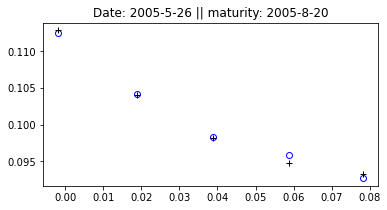

In [10]:
optimise_svi = svi.calibrate(print_options = [True, True])

### All slice-by-slice calibrations

Select a number of days

In [11]:
nbDates = 10

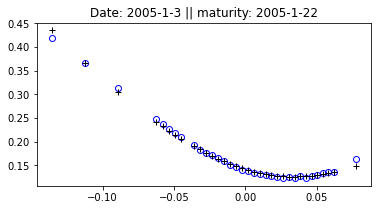

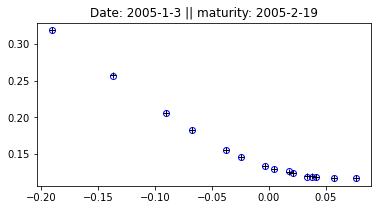

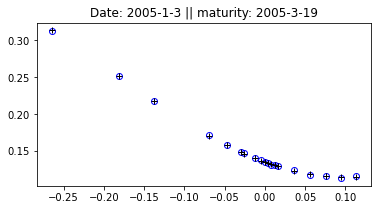

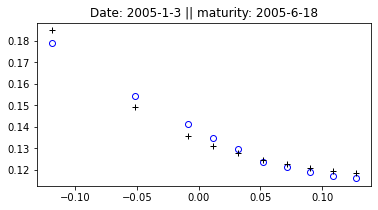

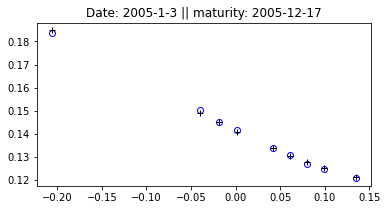

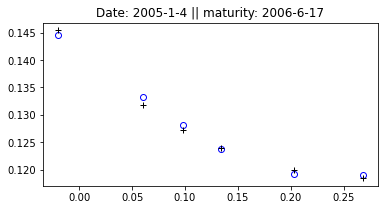

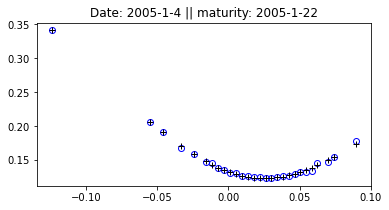

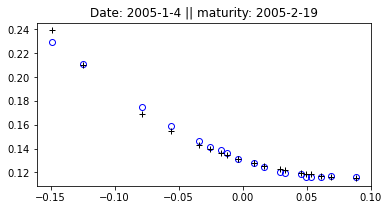

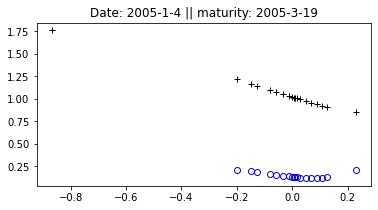

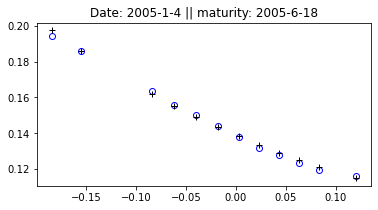

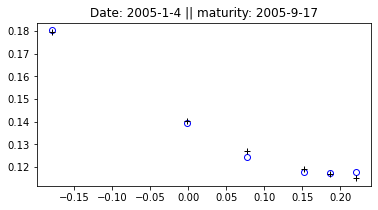

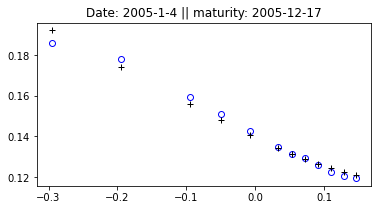

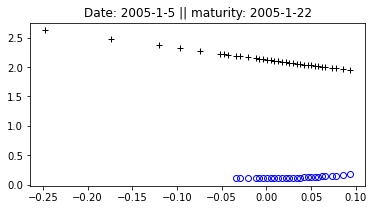

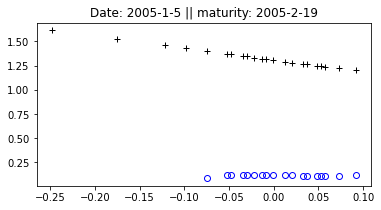

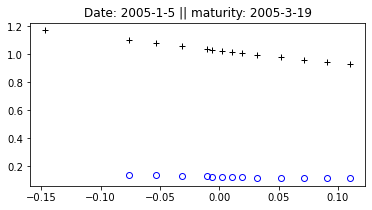

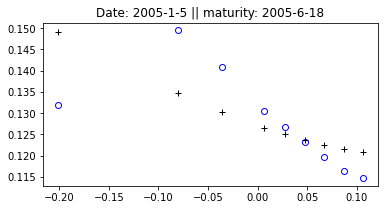

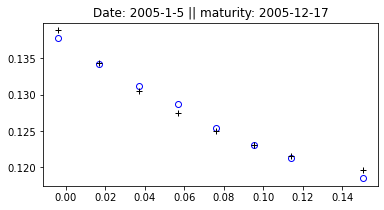

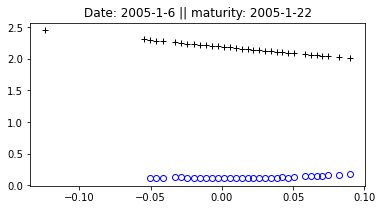

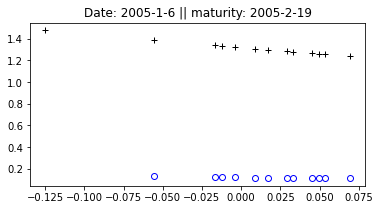

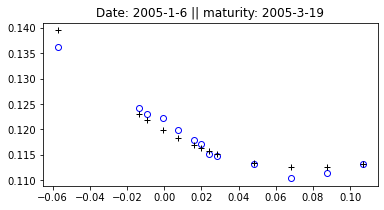

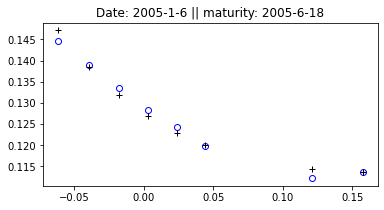

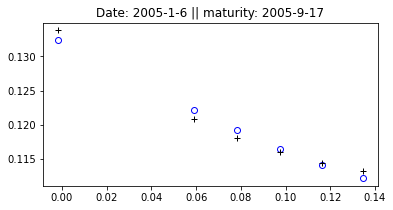

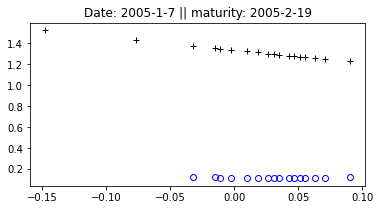

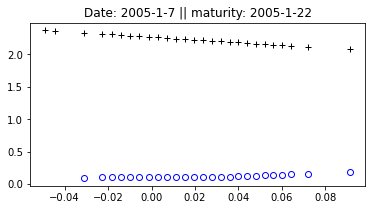

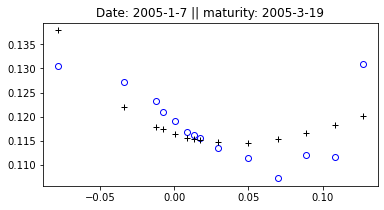

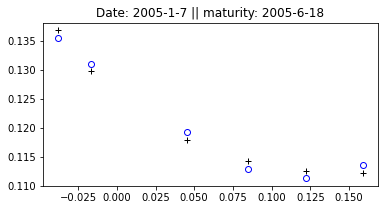

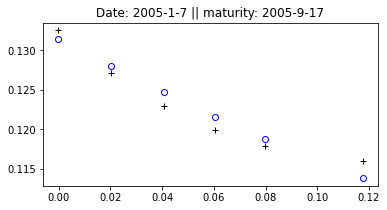

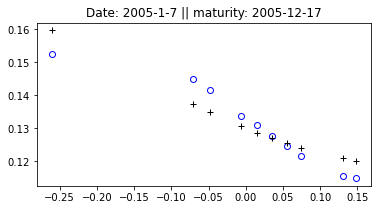

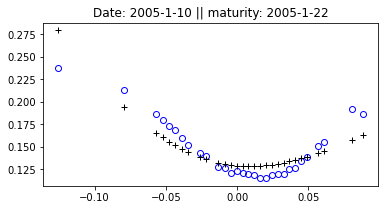

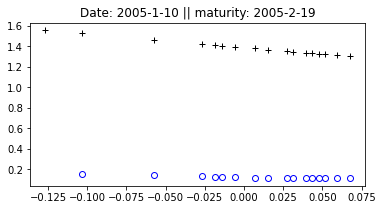

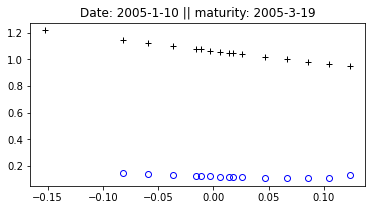

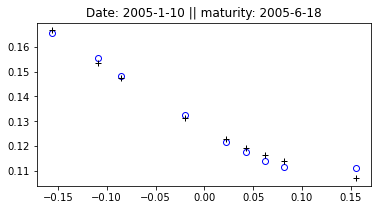

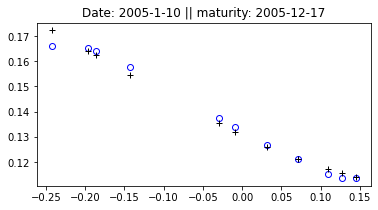

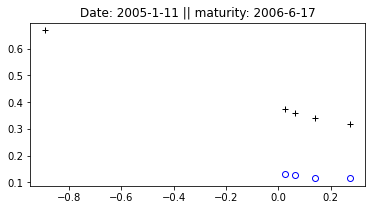

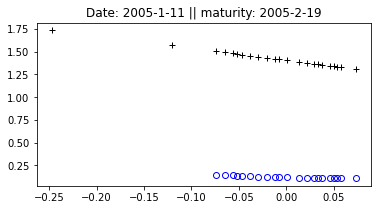

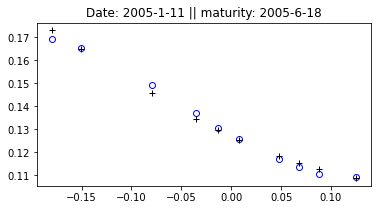

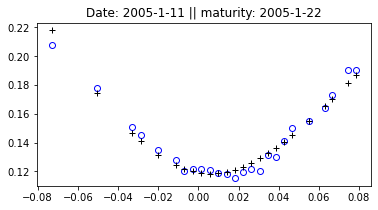

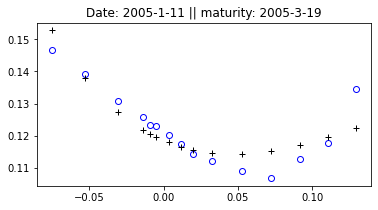

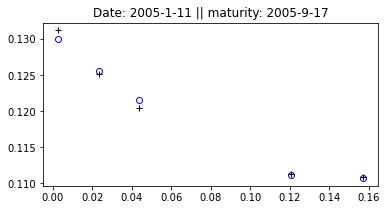

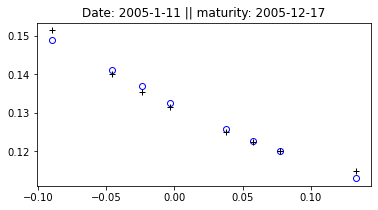

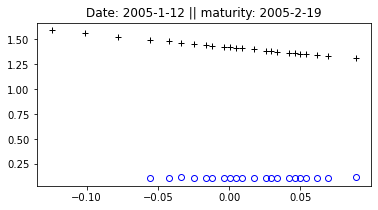

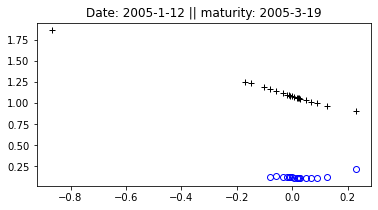

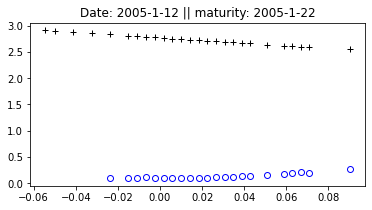

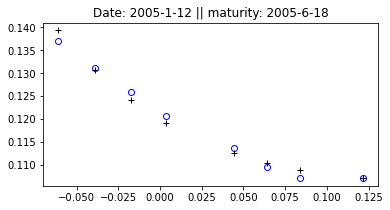

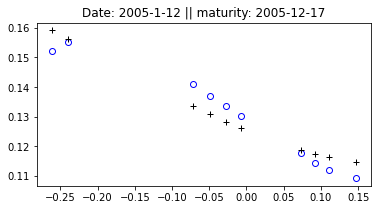

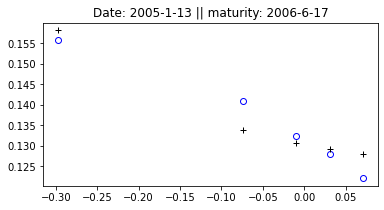

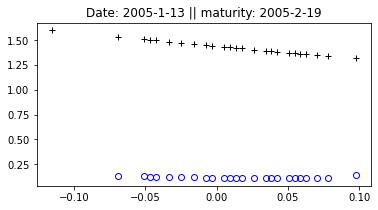

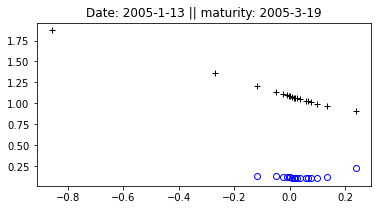

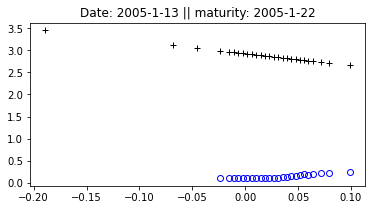

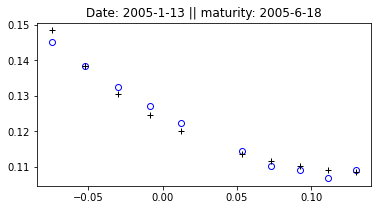

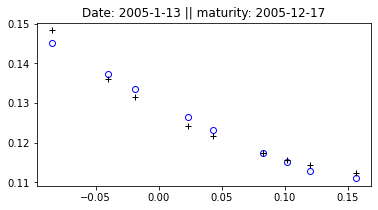

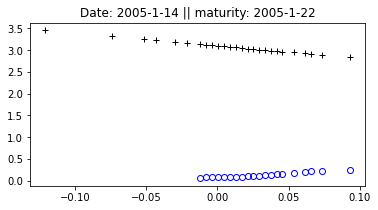

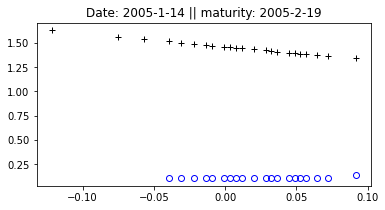

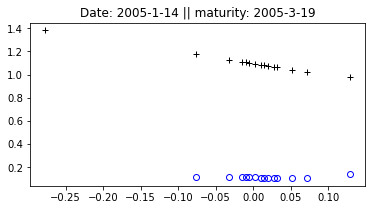

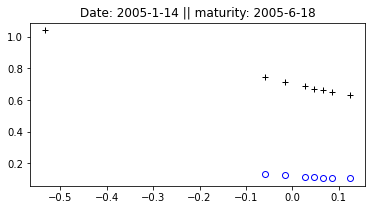

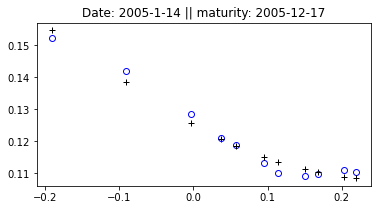

In [12]:
svi = model_calibration()

for (o_ind, o) in enumerate(cboeData.allDates[:nbDates]):
    for (ij, df_extract) in enumerate(cboeData.dfDict[o]):
        df = df_extract[0][df_extract[0]["cp_flag"] == "C"]
        if len(df) > 4: ## insufficient data otherwise
            df["logfwdmoneyness"] = -np.log(df["forward_price"] / df["strike"])
            svi.select_data(cboeData, o_ind, ij)
            optimise_svi = svi.calibrate(print_options = [False, True])